# Animation — orbit & frame-by-frame

Three deliverables on top of a built scene:

- **`orbit`** — sweep the camera around the scene and write a GIF/MP4 fly-through.
- **`animate`** — drive a frame-by-frame animation from a sequence of states via an `update` callback.
- **`jupyter`** — switch PyVista to the trame backend for an interactive widget in a live notebook.

GIF/MP4 writing needs `imageio` / `imageio-ffmpeg` (both in the `3d` extra). A `.mp4`/`.mov`/`.avi` path writes a movie; anything else a GIF.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

pv.OFF_SCREEN = True  # headless: every scene renders to an image, no interactive window

from pyramids.dataset import Dataset
from digitalearth.sources import get_source
from digitalearth.three_d import Scene3D

ROOT = Path.cwd()
while not (ROOT / 'examples' / 'data' / 'LisbonElevation.tif').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / 'examples' / 'data'

def show(scene, title=''):
    """Screenshot a scene off-screen and show it inline, asserting the scene area is not blank."""
    img = scene.screenshot()
    bg = img[0, 0].astype(int)
    area = img[: int(img.shape[0] * 0.8)]          # exclude the bottom colour-bar strip
    content = (np.abs(area.astype(int) - bg).sum(-1) > 30).mean()
    assert content > 0.01, f'render looks blank: only {content:.1%} of the scene differs from the background'
    plt.figure(figsize=(6, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()


2026-06-11 21:05:50 | INFO | pyramids.base.config | Logging is configured.


## `orbit` — a camera fly-through

We orbit the Lisbon terrain and show the GIF inline (written to a temp dir, so there's no repo artifact).

orbit GIF bytes: 373649


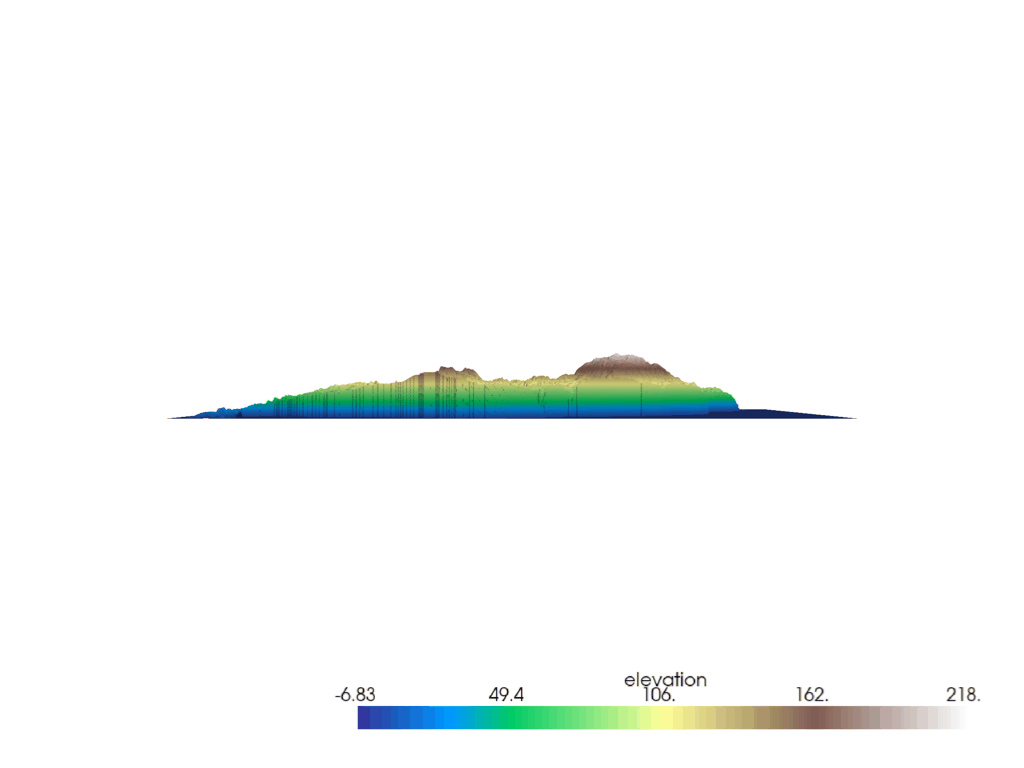

In [2]:
import tempfile, os
from IPython.display import Image as IPyImage, display
dem = Dataset.read_file(str(DATA / 'LisbonElevation.tif'))
scene = Scene3D(off_screen=True)
scene.terrain(dem, z_exaggeration=8.0, cmap='terrain')
gif = str(Path(tempfile.mkdtemp()) / 'orbit.gif')
scene.orbit(gif, n_frames=18, framerate=12)
scene.close()
print('orbit GIF bytes:', os.path.getsize(gif))
display(IPyImage(filename=gif))

## `animate` — a custom frame loop

`animate(frames, path, update)` calls `update(scene, frame)` before capturing each frame. Here we sweep the camera azimuth ourselves to spin an isosurface — any per-frame scene mutation works (swap scalars, re-add a layer, walk a `DatasetCollection` time stack…).

animate GIF bytes: 213966


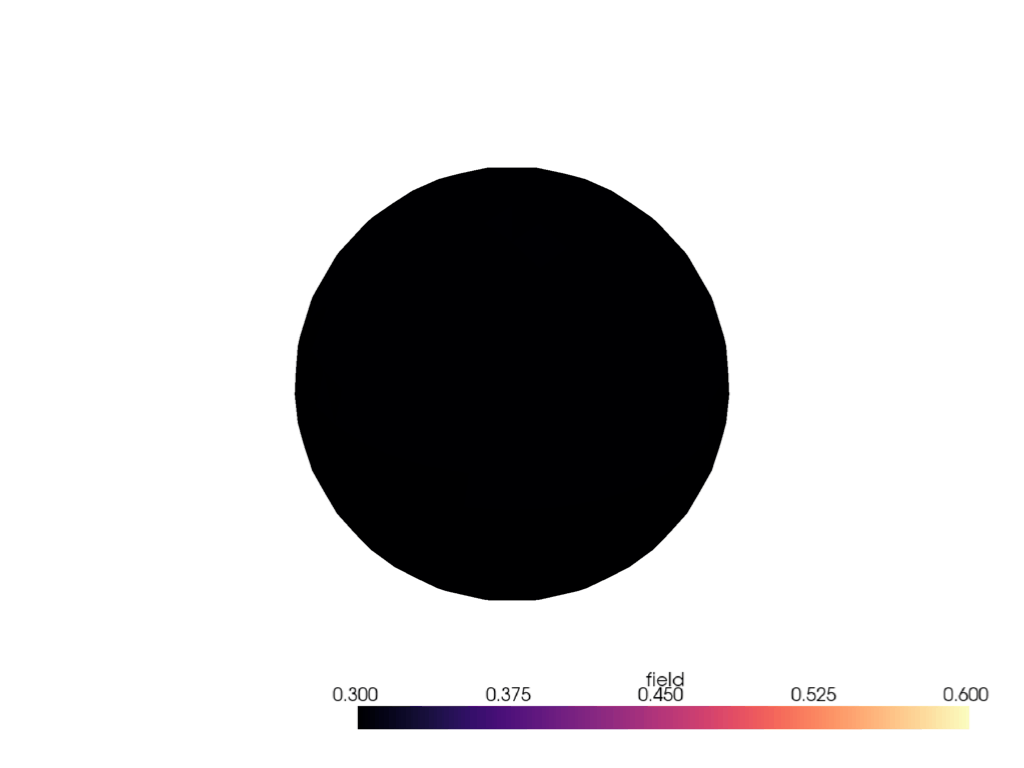

In [3]:
axis = np.linspace(-2, 2, 24)
X, Y, Z = np.meshgrid(axis, axis, axis, indexing='ij')
cube = np.exp(-(X**2 + Y**2 + Z**2))
scene = Scene3D(off_screen=True)
scene.isosurface(cube, isosurfaces=[0.3, 0.6], cmap='magma')

def spin(s, azimuth):
    s.plotter.camera.azimuth = azimuth

gif = str(Path(tempfile.mkdtemp()) / 'spin.gif')
scene.animate(range(0, 360, 20), gif, spin, framerate=12)
scene.close()
print('animate GIF bytes:', os.path.getsize(gif))
display(IPyImage(filename=gif))

## Interactive display in a live notebook

In an interactive (non-headless) session, `scene.jupyter('trame')` switches PyVista to the trame backend so `scene.show()` renders an interactive widget you can rotate and zoom. We don't call it here because this notebook runs headless in CI, but the call is simply:

```python
scene.jupyter('trame')   # or 'client' (vtk.js), 'static', 'html'
scene.show()
```